In [64]:
import kagglehub
path = kagglehub.dataset_download("elikplim/eergy-efficiency-dataset")

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.


In [65]:
import os

if path:
    print(f"Path of file is : {os.listdir(path)}")
    filepath = os.path.join(path,'ENB2012_data.csv')
    print(filepath)
else:
  print("Path is not found")

Path of file is : ['ENB2012_data.csv']
/kaggle/input/eergy-efficiency-dataset/ENB2012_data.csv


In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

dataset = pd.read_csv(filepath)
print(f"Shape of Dataset : \n{dataset.shape}")
print(f"-"*50)
dataset.head()

Shape of Dataset : 
(768, 10)
--------------------------------------------------


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


**Features** :

*   X1: Relative Compactness -> It indicates how much building is exposed to externel environment.
*  X2: Surface Area -> It is the total exterior envelope exposed to the
environment, including walls, roof, and foundation
*  X3: Wall Area -> It indicates the total surface area of a building's vertical elements
*  X4: Roof Area -> it indicates the total inclined surface area of a building’s top covering
*  X5: Overall Height -> It indicates the total vertical distance from a defined ground level to the highest point of the structure
*  X6: Orientation -> It  refers to the positioning of a structure on a site in relation to the sun's path, prevailing wind directions, and surrounding environment
*  X7: Glazing Area -> It refers to the total surface measurement of all transparent or translucent materials—primarily glass—on a building's exterior envelope, including windows, doors, and skylights.
*  X8: Glazing Area Distribution -> It refers to the intentional layout and percentage of transparent surfaces (windows, glass doors, curtain walls) placed on a building's facade relative to solid walls.


---
**Targets** :

*   y1: Heating Load -> The amount of heat energy that must be added to a space per hour to maintain a comfortable, consistent indoor temperature during cold weathe
*   y2: Cooling Load -> The amount of heat energy that must be removed from an indoor space to maintain a desired, comfortable temperature and humidity level


In [67]:
dataset = dataset.rename(columns= {'X1': 'Relative_Compactness','X2': 'Surface_Area','X3': 'Wall Area','X4': 'Roof_Area','X5': 'Overall_Height','X6': 'Orientation','X7': 'Glazing_Area','X8': 'Glazing_Area_Distribution','Y1': 'Heating_load','Y2': 'Cooling_Load' })
dataset.head()

,Relative_Compactness,Surface_Area,Wall Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [68]:
dataset.tail()

,Relative_Compactness,Surface_Area,Wall Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_load,Cooling_Load
763,0.64,784.0,343.0,220.5,3.5,5,0.4,5,17.88,21.40
764,0.62,808.5,367.5,220.5,3.5,2,0.4,5,16.54,16.88
765,0.62,808.5,367.5,220.5,3.5,3,0.4,5,16.44,17.11
766,0.62,808.5,367.5,220.5,3.5,4,0.4,5,16.48,16.61
767,0.62,808.5,367.5,220.5,3.5,5,0.4,5,16.64,16.03


# Data Exploration

In [69]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       768 non-null    float64
 1   Surface_Area               768 non-null    float64
 2   Wall Area                  768 non-null    float64
 3   Roof_Area                  768 non-null    float64
 4   Overall_Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing_Area               768 non-null    float64
 7   Glazing_Area_Distribution  768 non-null    int64  
 8   Heating_load               768 non-null    float64
 9   Cooling_Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [70]:
#Checks for Missing Value
print(f"Missing Values :\n{dataset.isnull().sum()}")

Missing Values :
Relative_Compactness         0
Surface_Area                 0
Wall Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_load                 0
Cooling_Load                 0
dtype: int64


In [71]:
# Check for Duplication
print(f"Number of Duplicates : {dataset.duplicated().sum()}")

Number of Duplicates : 0


There is no missing and duplicate value in dataset

In [72]:
# Checking how many unique values each data_row contain
for i,column in enumerate(dataset.columns,1):
  print(f"'{i}'".center(50,'-'))
  print(f"Unique values in {column} : {dataset[column].value_counts(ascending=True)}")

-----------------------'1'------------------------
Unique values in Relative_Compactness : Relative_Compactness
0.98    64
0.90    64
0.86    64
0.82    64
0.79    64
0.76    64
0.74    64
0.71    64
0.69    64
0.66    64
0.64    64
0.62    64
Name: count, dtype: int64
-----------------------'2'------------------------
Unique values in Surface_Area : Surface_Area
514.5    64
563.5    64
588.0    64
612.5    64
637.0    64
661.5    64
686.0    64
710.5    64
735.0    64
759.5    64
784.0    64
808.5    64
Name: count, dtype: int64
-----------------------'3'------------------------
Unique values in Wall Area : Wall Area
416.5     64
367.5     64
269.5     64
245.0     64
343.0    128
318.5    192
294.0    192
Name: count, dtype: int64
-----------------------'4'------------------------
Unique values in Roof_Area : Roof_Area
110.25     64
122.50    128
147.00    192
220.50    384
Name: count, dtype: int64
-----------------------'5'------------------------
Unique values in Overall_Height : 

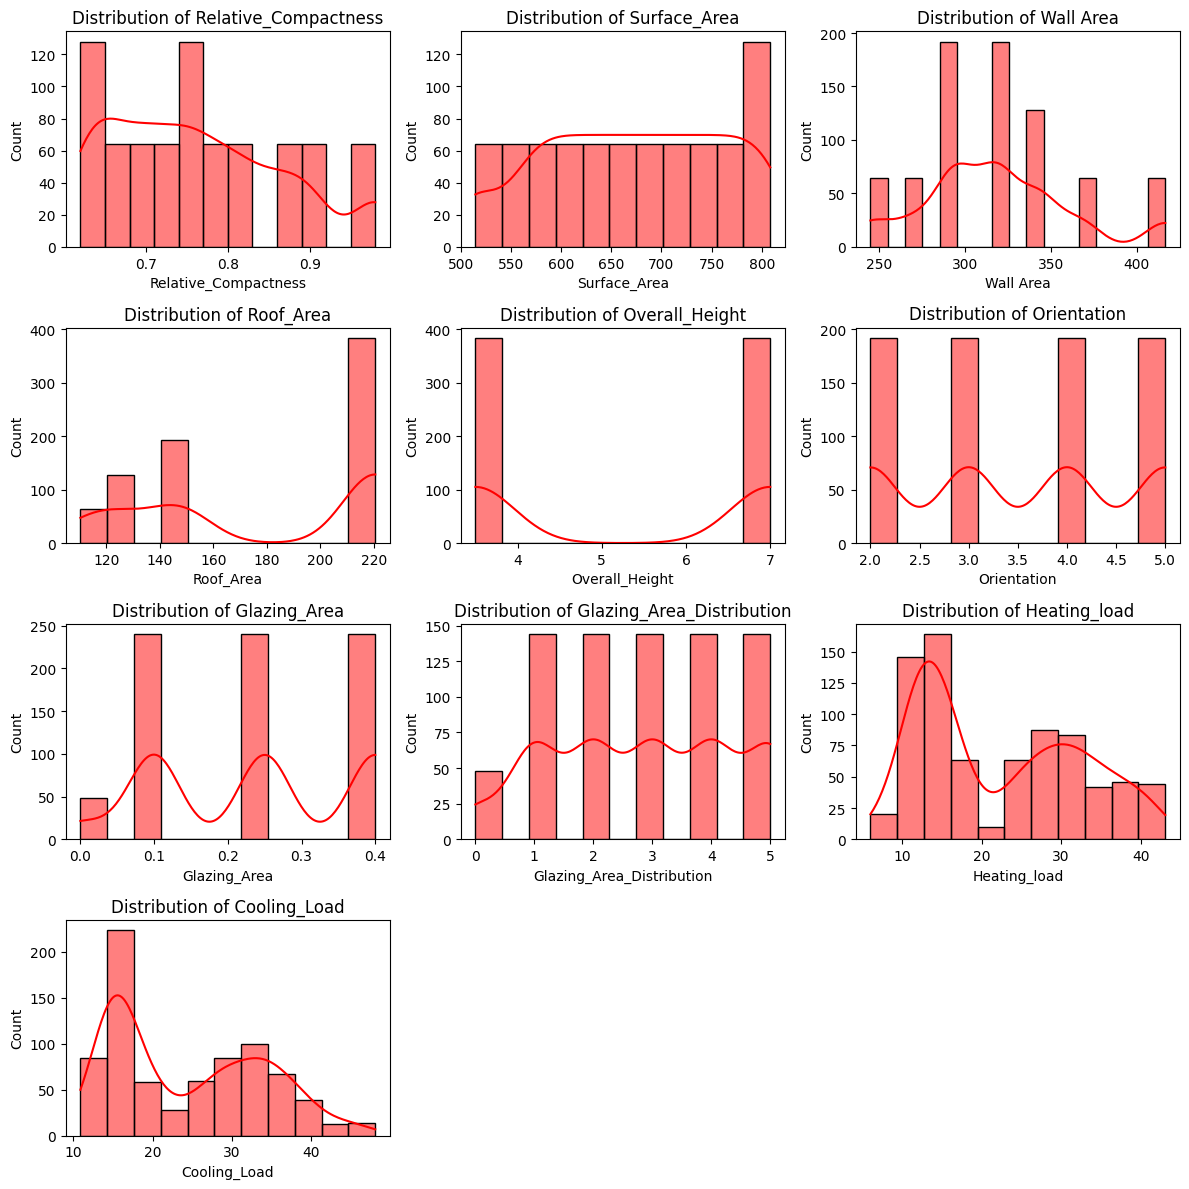

In [73]:
# Visualizing distribution
plt.figure(figsize=(12,12))
for i,column in enumerate(dataset.columns,1):
  plt.subplot(4,3,i)
  sns.histplot(data=dataset, x=column, kde = True,color = 'red')
  plt.title(f"Distribution of {column}")
  plt.tight_layout()
plt.show()

In [74]:
dataset.describe()

,Relative_Compactness,Surface_Area,Wall Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_load,Cooling_Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


Based on univariate analysis:


*   Heating Load,Cooling Load follows continuous distribution.
*  Overall Height,Orientation,Glazing Area,Glazing Area Distribution follows discrete distribution.



Bivariate Analysis

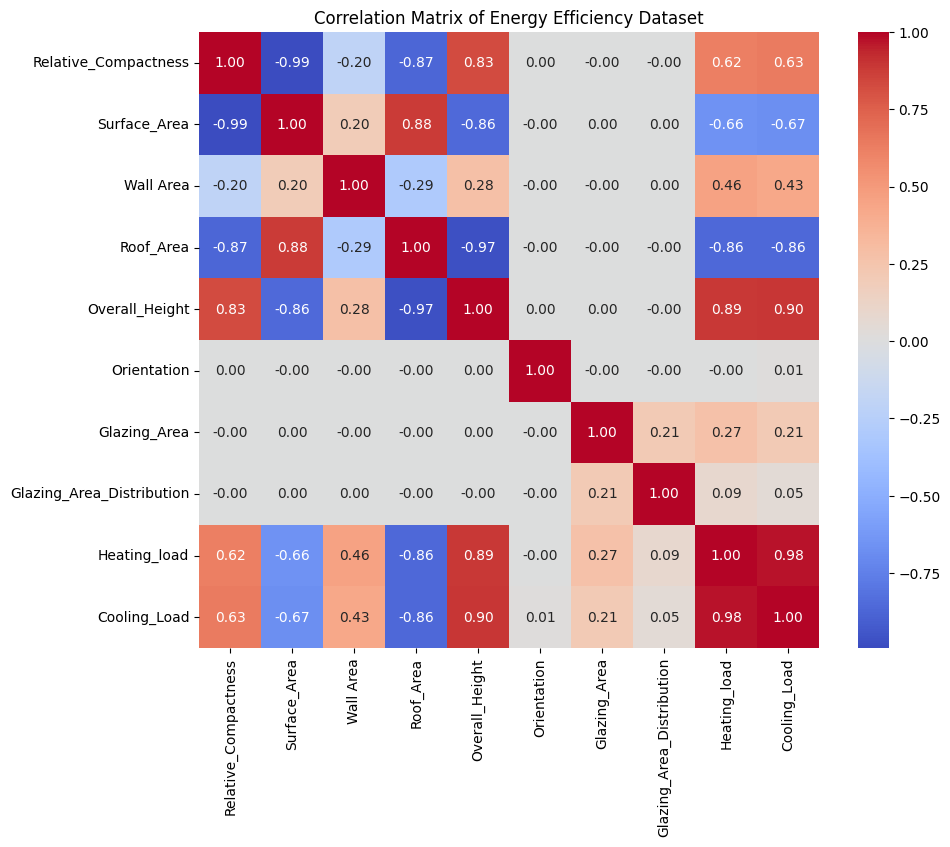

In [75]:
corr = dataset.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Energy Efficiency Dataset')
plt.show()

Key Insights:

*   Relative compactness shows postive relation(~0.6) with Heating and Cooling Load while shows negative correlation with surface and roof area.
*   Surface Area shows negative relation with Heating and Cooling Load while shows positive correlation with roof area.
*   Heating Load has shows a postive correlation with Cooling Load.Both targets shows correlation.





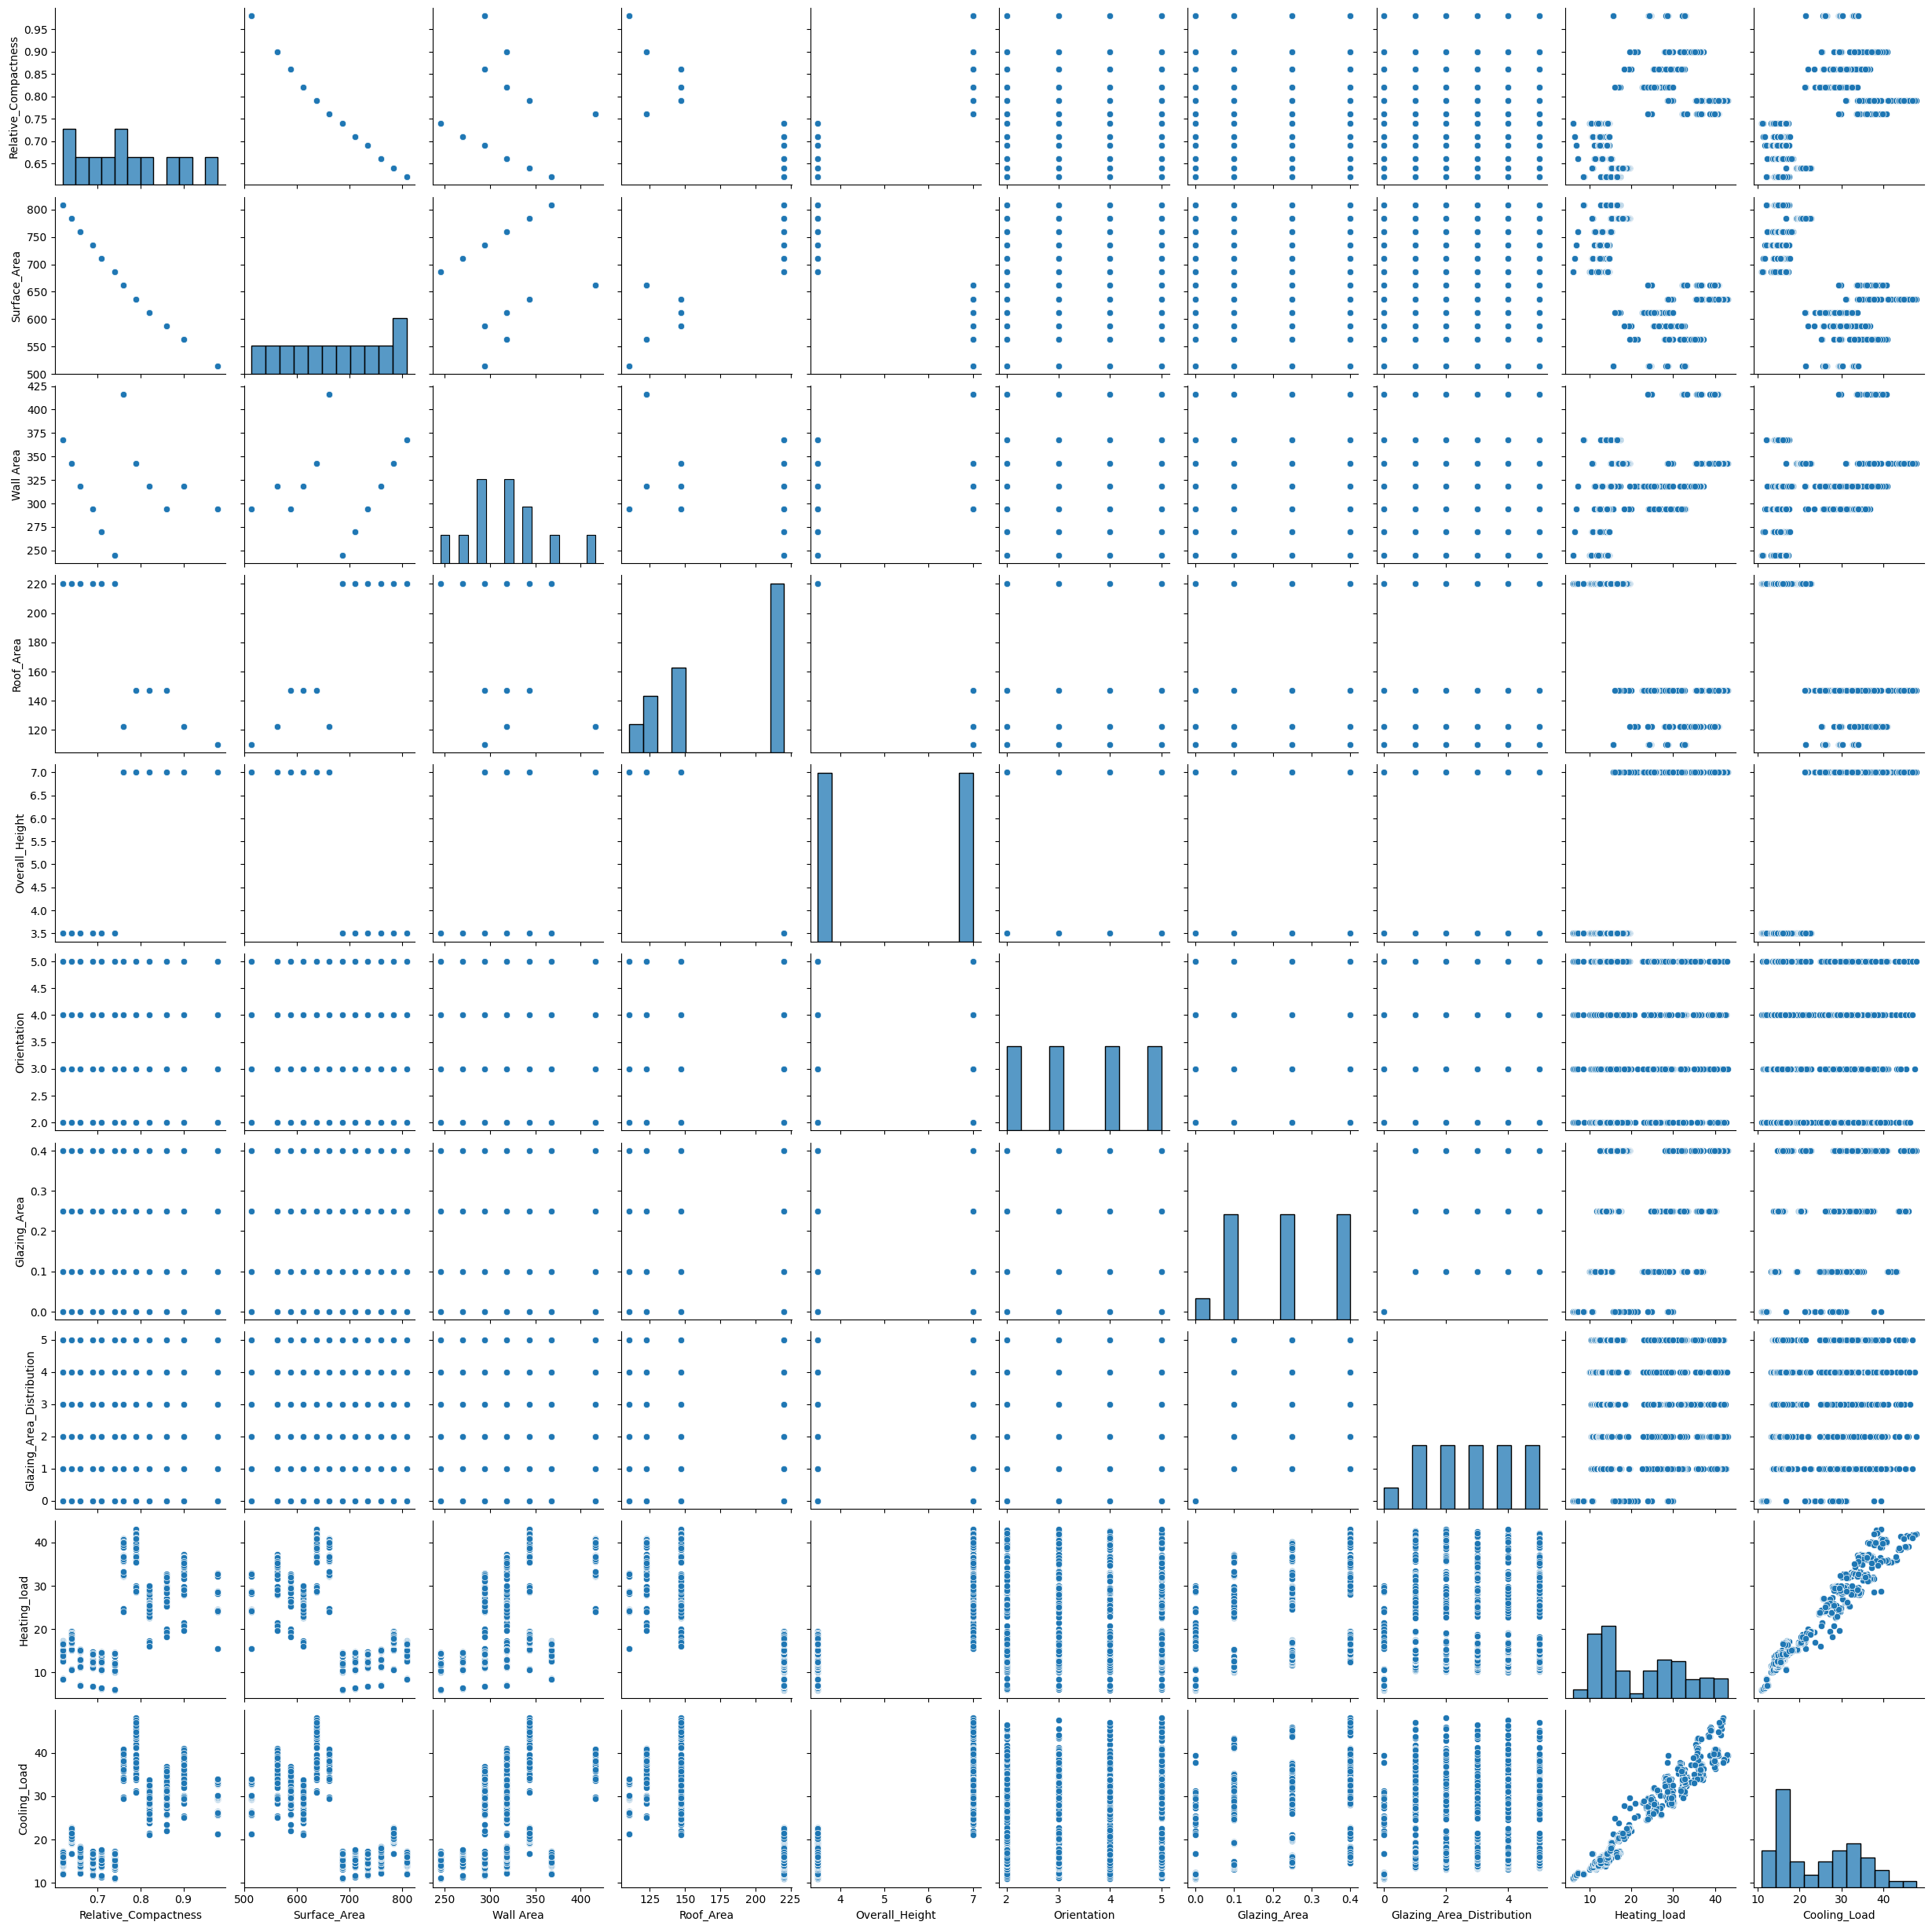

In [76]:
sns.pairplot(dataset)
plt.show()

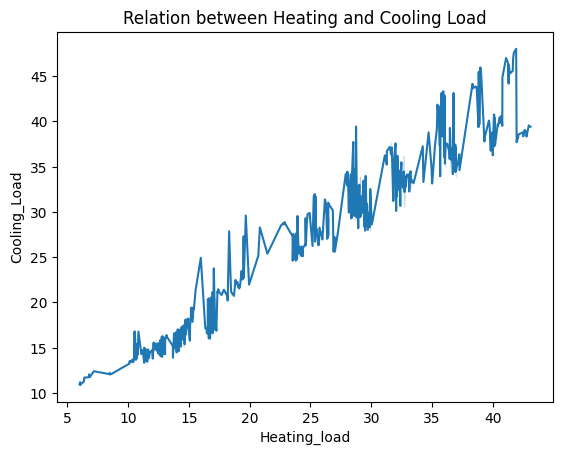

In [77]:
sns.lineplot(x = 'Heating_load',y = 'Cooling_Load',data = dataset)
plt.title("Relation between Heating and Cooling Load")
plt.show()

Developing Models on Dataset

In [84]:
# Splitting dataset for train test and split
X = dataset.drop(columns = ['Heating_load','Cooling_Load'])
y_1 = dataset['Heating_load']
y_2 = dataset['Cooling_Load']
from sklearn.model_selection import train_test_split
X_hl_train,X_hl_test,y_hl_train,y_hl_test = train_test_split(X,y_1,test_size = 0.2,random_state = 42)
X_cl_train,X_cl_test,y_cl_train,y_cl_test = train_test_split(X,y_2,test_size = 0.2,random_state = 42)


In [79]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

def evaluate_model(model,y,y_test,y_preds):
  mse = mean_squared_error(y_test,y_preds)
  mae = mean_absolute_error(y_test,y_preds)
  r_hl = r2_score(y_test,y_preds)
  print(f"Testing Prediction of {model} for {y}")
  print(f"Mean Squared Error : {mse:.2f}")
  print(f"Mean Absolute Error : {mae:.2f}")
  print(f"R2 Score : {r_hl}")


**Models for Heating Load**

Linear Regression Model


In [80]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_hl_train,y_hl_train)
y_preds = lr_model.predict(X_hl_test)

# Evaluating Model
evaluate_model('Linear Regression','Heating_load',y_hl_test,y_preds)

Testing Prediction of Linear Regression for Heating_load
Mean Squared Error : 9.15
Mean Absolute Error : 2.18
R2 Score : 0.912184095154691


Decision Tree Regressor

In [81]:
from sklearn.tree import DecisionTreeRegressor

dc_model = DecisionTreeRegressor()
dc_model.fit(X_hl_train,y_hl_train)
y_preds_1 = dc_model.predict(X_hl_test)

evaluate_model('Decision Tree Regressor','Heating_load',y_hl_test,y_preds)

Testing Prediction of Decision Tree Regressor for Heating_load
Mean Squared Error : 9.15
Mean Absolute Error : 2.18
R2 Score : 0.912184095154691


Random Forest Regressor

In [82]:
from sklearn.ensemble import RandomForestRegressor

rg_model = RandomForestRegressor(n_estimators = 4,max_depth = None,random_state = 42)
rg_model.fit(X_hl_train,y_hl_train)
y_preds_2 = rg_model.predict(X_hl_test)

evaluate_model('Random Forest Regressor','Heating_load',y_hl_test,y_preds_2)

Testing Prediction of Random Forest Regressor for Heating_load
Mean Squared Error : 0.30
Mean Absolute Error : 0.40
R2 Score : 0.9970896971470239


In [83]:
importances = pd.Series(rg_model.feature_importances_,index = X_hl_train.columns)
importance = importances.sort_values(ascending = False)
importance

,0
Relative_Compactness,0.366546
Surface_Area,0.190369
Overall_Height,0.157849
Roof_Area,0.155485
Glazing_Area,0.081747
Wall Area,0.037552
Glazing_Area_Distribution,0.009587
Orientation,0.000865


**Models for Cooling Load**

Linear Regression Model

In [85]:
lr_model_2 = LinearRegression()
lr_model_2.fit(X_cl_train,y_cl_train)
y_preds = lr_model_2.predict(X_cl_test)

# Evaluating Model
evaluate_model('Linear Regression','Cooling Load',y_cl_test,y_preds)

Testing Prediction of Linear Regression for Cooling Load
Mean Squared Error : 9.89
Mean Absolute Error : 2.20
R2 Score : 0.8932255268607288


Decision Tree Regressor

In [87]:
dc_model_2 = DecisionTreeRegressor()
dc_model_2.fit(X_cl_train,y_cl_train)
y_preds_1 = dc_model.predict(X_cl_test)

evaluate_model('Decision Tree Regressor','Heating_load',y_cl_test,y_preds_1)

Testing Prediction of Decision Tree Regressor for Heating_load
Mean Squared Error : 9.93
Mean Absolute Error : 2.72
R2 Score : 0.8928812863123172


Random Forest Regressor

In [88]:
rg_model = RandomForestRegressor(n_estimators = 4,max_depth = None,random_state = 42)
rg_model.fit(X_cl_train,y_cl_train)
y_preds_2 = rg_model.predict(X_cl_test)

evaluate_model('Random Forest Regressor','Heating_load',y_cl_test,y_preds_2)

Testing Prediction of Random Forest Regressor for Heating_load
Mean Squared Error : 4.55
Mean Absolute Error : 1.30
R2 Score : 0.9508761698178798


In [90]:
importances = pd.Series(rg_model.feature_importances_,index = X_cl_train.columns)
importance = importances.sort_values(ascending = False)
importance

,0
Overall_Height,0.403353
Relative_Compactness,0.218763
Roof_Area,0.200544
Surface_Area,0.068250
Glazing_Area,0.051406
Wall Area,0.029959
Glazing_Area_Distribution,0.016039
Orientation,0.011685
